# DETECTOR DE FUNDAMENTALES Y ARMÓNICOS

La idea consiste en tomar el micrófono de referencia que tiene la mejor toma con mejor SNR de cada grabación por cada giro de la mesa giratoria. A esa grabación procesarla y encontrar las frecuencias fundamentales que se tienen y en que instante suceden.

## Levantar directorio de audios

In [56]:
import librosa          # audio, F0, STFT
import numpy as np      # matrices y cálculos
import soundfile as sf  # leer WAVs (más rápido que librosa.load)
import matplotlib.pyplot as plt  # plots
import ipywidgets       # sliders interactivos en el notebook
import soundfile as sf
import numpy as np
from pathlib import Path
import re
from IPython.display import Audio, display

### Directorio y formato de archivos

In [57]:

# ── Configuración ──────────────────────────────────────────────────────────────
PATH = r'D:\UNTREF\IMA\TP5 - PATRON POLAR\procesados'

PLANTILLA_MICS = r'mic_(?P<MIC>\d+)_ang_(?P<DIN>\w+)_(?P<ANG>\d+)\.wav'
PLANTILLA_REF  = r'mic_ref_ang_(?P<DIN>\w+)_(?P<ANG>\d+)_alineado\.wav'
PLANTILLA_CAL  = r'mic_(?P<MIC>\d+)_ang_cal\.wav'

carpeta_base  = Path(PATH)
carpeta_media = carpeta_base / 'media'
carpeta_ref   = carpeta_base / 'referencia'
carpeta_cal   = carpeta_base / 'cal'

patron_mic = re.compile(PLANTILLA_MICS, re.IGNORECASE)
patron_ref = re.compile(PLANTILLA_REF,  re.IGNORECASE)
patron_cal = re.compile(PLANTILLA_CAL,  re.IGNORECASE)

# ── Paso 1: cargar todo en diccionarios temporales ────────────────────────────
# (igual que antes, para poder determinar n_muestras antes de crear los tensores)
mics_dict = {}   # [din][ang][mic] = señal
refs_dict = {}   # [din][ang]      = señal
cal_dict  = {}   # [mic]           = señal
sr_global = None

for wav in sorted(carpeta_media.rglob('*.wav')):
    m = patron_mic.match(wav.name)
    if not m: continue
    mic, din, ang = int(m.group('MIC')), m.group('DIN').lower(), int(m.group('ANG'))
    sig, sr = sf.read(str(wav), dtype='float32')
    if sig.ndim > 1: sig = sig[:, 0]
    if sr_global is None: sr_global = sr
    mics_dict.setdefault(din, {}).setdefault(ang, {})[mic] = sig

for wav in sorted(carpeta_ref.rglob('*.wav')):
    m = patron_ref.match(wav.name)
    if not m: continue
    din, ang = m.group('DIN').lower(), int(m.group('ANG'))
    sig, sr = sf.read(str(wav), dtype='float32')
    if sig.ndim > 1: sig = sig[:, 0]
    refs_dict.setdefault(din, {})[ang] = sig

for wav in sorted(carpeta_cal.rglob('*.wav')):
    m = patron_cal.match(wav.name)
    if not m: continue
    mic = int(m.group('MIC'))
    sig, sr = sf.read(str(wav), dtype='float32')
    if sig.ndim > 1: sig = sig[:, 0]
    cal_dict[mic] = sig


# ── Paso 2: determinar dimensiones ────────────────────────────────────────────
dinamicas     = sorted(mics_dict.keys())           # ['forte', 'piano']
angulos_mesa  = sorted(mics_dict[dinamicas[0]].keys())  # [0, 10, ..., 180]
numeros_mics  = sorted(mics_dict[dinamicas[0]][angulos_mesa[0]].keys())  # [1..19]

N_MICS    = len(numeros_mics)   # 19
N_ANGULOS = len(angulos_mesa)   # 19

# Largo mínimo entre todos los archivos → para que todos los tensores tengan
# el mismo n_muestras
n_muestras = min(
    len(mics_dict[din][ang][mic])
    for din in dinamicas
    for ang in angulos_mesa
    for mic in numeros_mics
)

n_muestras_ref = min(
    len(refs_dict[din][ang])
    for din in dinamicas
    for ang in angulos_mesa
    if ang in refs_dict.get(din, {})
)

n_muestras_cal = min(len(s) for s in cal_dict.values())

print(f"Sample rate:    {sr_global} Hz")
print(f"Dinámicas:      {dinamicas}")
print(f"Ángulos mesa:   {angulos_mesa}")
print(f"Micrófonos:     {numeros_mics}")
print(f"n_muestras:     {n_muestras}  ({n_muestras/sr_global:.2f} s)")
print()

# ── Paso 3: construir tensores ────────────────────────────────────────────────
tensor_forte = np.zeros((N_MICS, N_ANGULOS, n_muestras),     dtype=np.float32)
tensor_piano = np.zeros((N_MICS, N_ANGULOS, n_muestras),     dtype=np.float32)
tensor_refs_forte = np.zeros((N_ANGULOS, n_muestras_ref),    dtype=np.float32)
tensor_refs_piano = np.zeros((N_ANGULOS, n_muestras_ref),    dtype=np.float32)
tensor_cal        = np.zeros((N_MICS, n_muestras_cal),       dtype=np.float32)

for i_ang, ang in enumerate(angulos_mesa):
    for i_mic, mic in enumerate(numeros_mics):
        tensor_forte[i_mic, i_ang, :] = mics_dict['forte'][ang][mic][:n_muestras]
        tensor_piano[i_mic, i_ang, :] = mics_dict['piano'][ang][mic][:n_muestras]
    tensor_refs_forte[i_ang, :] = refs_dict['forte'][ang][:n_muestras_ref]
    tensor_refs_piano[i_ang, :] = refs_dict['piano'][ang][:n_muestras_ref]

for i_mic, mic in enumerate(numeros_mics):
    tensor_cal[i_mic, :] = cal_dict[mic][:n_muestras_cal]

# ── Resumen ────────────────────────────────────────────────────────────────────
print(f"tensor_forte:      {tensor_forte.shape}  →  {tensor_forte.nbytes/1e6:.1f} MB")
print(f"tensor_piano:      {tensor_piano.shape}  →  {tensor_piano.nbytes/1e6:.1f} MB")
print(f"tensor_refs_forte: {tensor_refs_forte.shape}")
print(f"tensor_refs_piano: {tensor_refs_piano.shape}")
print(f"tensor_cal:        {tensor_cal.shape}")

Sample rate:    44100 Hz
Dinámicas:      ['forte', 'piano']
Ángulos mesa:   [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180]
Micrófonos:     [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
n_muestras:     520116  (11.79 s)

tensor_forte:      (19, 19, 520116)  →  751.0 MB
tensor_piano:      (19, 19, 520116)  →  751.0 MB
tensor_refs_forte: (19, 269010)
tensor_refs_piano: (19, 269010)
tensor_cal:        (19, 84916)


## Levantar audios desde el tensor y graficar la fundamental en funcion del tiempo

In [58]:
# Referencia mesa 90°, forte


i_ang = angulos_mesa.index(90)

señal_ref = tensor_refs_forte[i_ang, :]

Audio(señal_ref, rate=sr_global)

In [59]:
# Detectar F0 con pYIN
# fmin y fmax acotan la búsqueda al rango de tu cantante (F4 a F5)
f0, voiced_flag, voiced_prob = librosa.pyin(
    señal_ref,
    fmin        = librosa.note_to_hz('C4'),  # 349 Hz
    fmax        = librosa.note_to_hz('C6'),  # 698 Hz
    sr          = sr_global,
    frame_length= 2048,   # ventana de análisis (~46ms a 44100Hz)
    hop_length  = 512     # salto entre frames (~11ms)
)

# f0 es un array con la frecuencia fundamental en cada frame
# voiced_flag indica si hay voz (True) o silencio (False) en ese frame
# Los frames sin voz tienen f0 = NaN

# Eje temporal
tiempos = librosa.frames_to_time(
    np.arange(len(f0)),
    sr         = sr_global,
    hop_length = 512
)

print(f"Frames totales:  {len(f0)}")
print(f"Frames con voz:  {voiced_flag.sum()}")
print(f"F0 mín detectada: {np.nanmin(f0):.1f} Hz")
print(f"F0 máx detectada: {np.nanmax(f0):.1f} Hz")
print(f"Resolución temporal: {512/sr_global*1000:.1f} ms por frame")

Frames totales:  526
Frames con voz:  475
F0 mín detectada: 314.7 Hz
F0 máx detectada: 793.1 Hz
Resolución temporal: 11.6 ms por frame


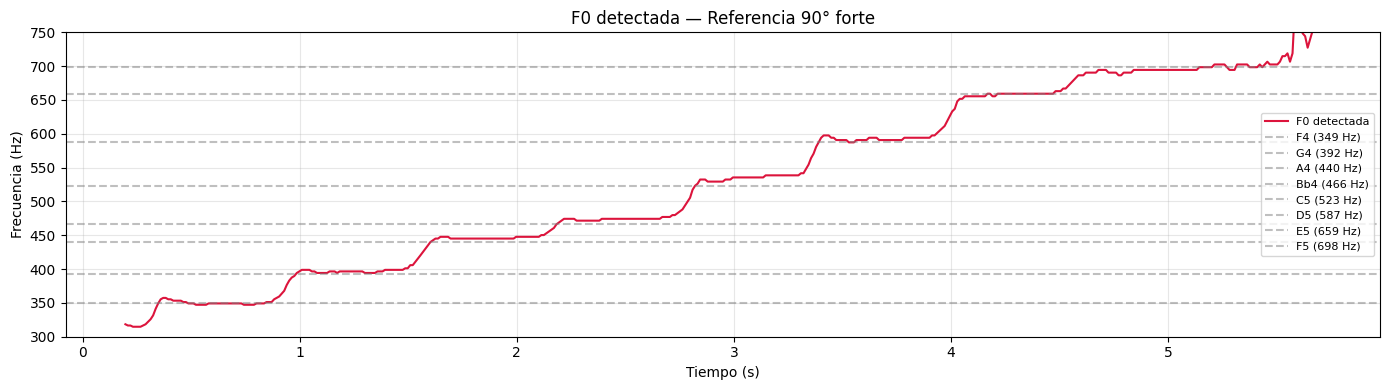

In [60]:


fig, ax = plt.subplots(figsize=(14, 4))

# Solo graficar donde hay voz
f0_voiced = f0.copy()
f0_voiced[~voiced_flag] = np.nan

ax.plot(tiempos, f0_voiced, color='crimson', linewidth=1.5, label='F0 detectada')
ax.axhline(librosa.note_to_hz('F4'), color='gray', linestyle='--', alpha=0.5, label='F4 (349 Hz)')
ax.axhline(librosa.note_to_hz('G4'), color='gray', linestyle='--', alpha=0.5, label='G4 (392 Hz)')
ax.axhline(librosa.note_to_hz('A4'), color='gray', linestyle='--', alpha=0.5, label='A4 (440 Hz)')
ax.axhline(librosa.note_to_hz('Bb4'), color='gray', linestyle='--', alpha=0.5, label='Bb4 (466 Hz)')
ax.axhline(librosa.note_to_hz('C5'), color='gray', linestyle='--', alpha=0.5, label='C5 (523 Hz)')
ax.axhline(librosa.note_to_hz('D5'), color='gray', linestyle='--', alpha=0.5, label='D5 (587 Hz)')
ax.axhline(librosa.note_to_hz('E5'), color='gray', linestyle='--', alpha=0.5, label='E5 (659 Hz)')
ax.axhline(librosa.note_to_hz('F5'), color='gray', linestyle='--', alpha=0.5, label='F5 (698 Hz)')

ax.set_xlabel('Tiempo (s)')
ax.set_ylabel('Frecuencia (Hz)')
ax.set_title('F0 detectada — Referencia 90° forte')
ax.legend(loc='right', fontsize=8)
ax.set_ylim(300, 750)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Multiples graficos 5 wav x grafico

In [61]:
f0_refs      = {}
voiced_refs  = {}
prob_refs    = {}   # ← nuevo: probabilidad de confianza

for i_ang, ang in enumerate(angulos_mesa):
    señal = tensor_refs_forte[i_ang, :]
    f0, voiced, prob = librosa.pyin(
        señal,
        fmin         = librosa.note_to_hz('F4'),
        fmax         = librosa.note_to_hz('F5'),
        sr           = sr_global,
        frame_length = 2048,
        hop_length   = 512
    )
    
    f0_refs[ang]     = f0
    voiced_refs[ang] = voiced
    prob_refs[ang]   = prob   # ← guardar probabilidad

    # Frames con alta confianza
    n_confiables = np.sum(prob > 0.8)
    print(f"  ángulo {ang:>4}°  →  {voiced.sum()} frames con voz  |  "
          f"{n_confiables} con confianza >80%")

  ángulo    0°  →  475 frames con voz  |  437 con confianza >80%
  ángulo   10°  →  475 frames con voz  |  469 con confianza >80%
  ángulo   20°  →  476 frames con voz  |  465 con confianza >80%
  ángulo   30°  →  475 frames con voz  |  432 con confianza >80%
  ángulo   40°  →  475 frames con voz  |  432 con confianza >80%
  ángulo   50°  →  475 frames con voz  |  439 con confianza >80%
  ángulo   60°  →  476 frames con voz  |  449 con confianza >80%
  ángulo   70°  →  475 frames con voz  |  458 con confianza >80%
  ángulo   80°  →  476 frames con voz  |  450 con confianza >80%
  ángulo   90°  →  476 frames con voz  |  433 con confianza >80%
  ángulo  100°  →  476 frames con voz  |  465 con confianza >80%
  ángulo  110°  →  475 frames con voz  |  443 con confianza >80%
  ángulo  120°  →  476 frames con voz  |  460 con confianza >80%
  ángulo  130°  →  475 frames con voz  |  433 con confianza >80%
  ángulo  140°  →  476 frames con voz  |  460 con confianza >80%
  ángulo  150°  →  476 fr

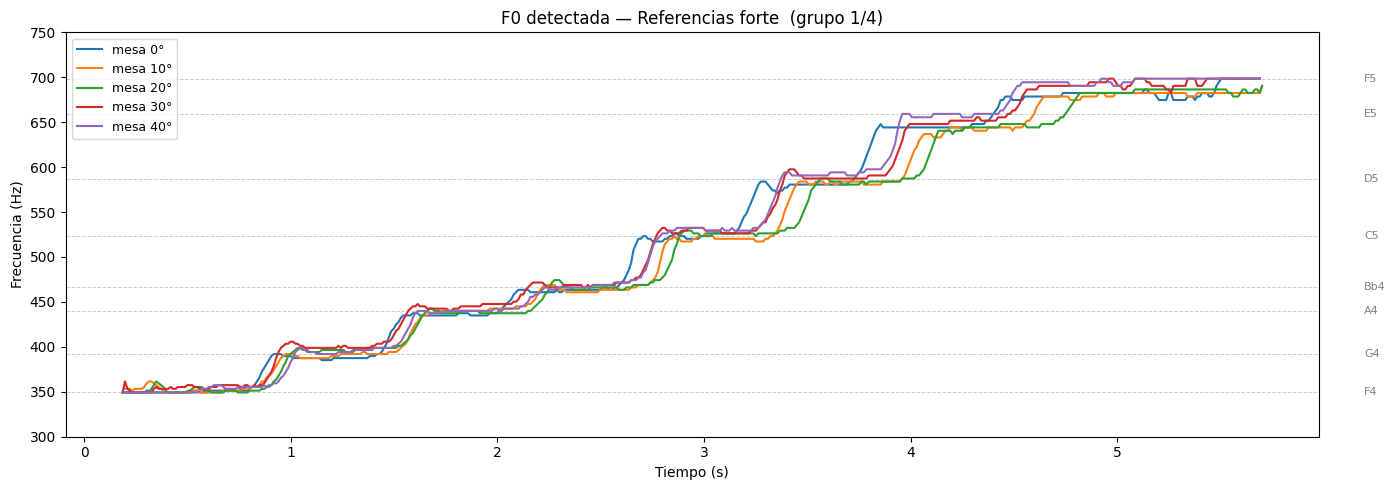

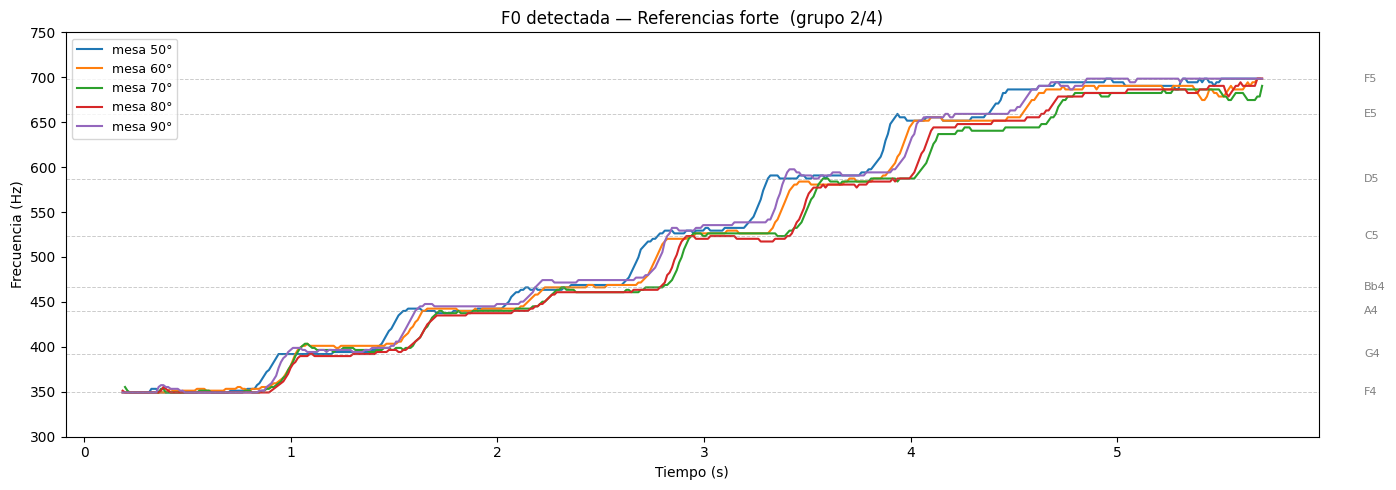

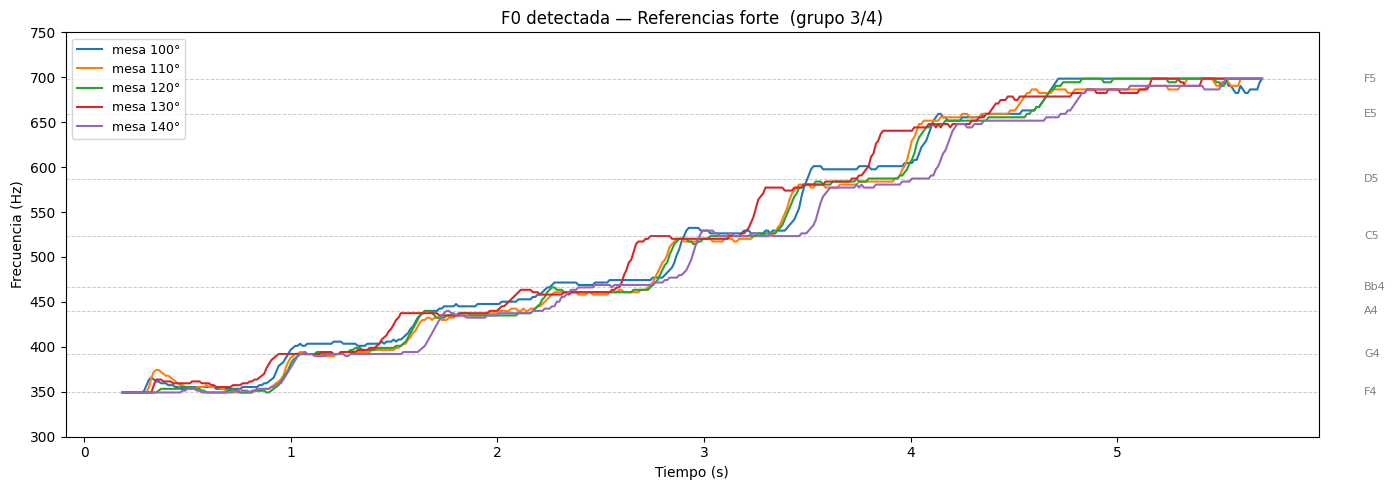

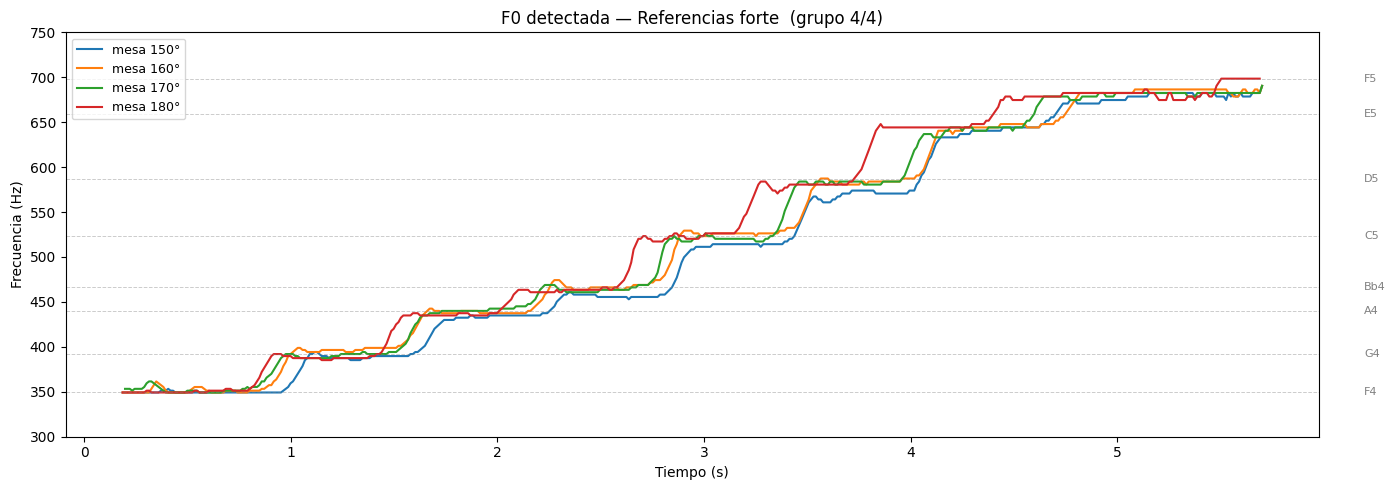

In [62]:
# ── Graficar 5 ángulos por figura, todos en un mismo gráfico ──────────────────
# Fa, Sol, La, Si bemol, Do, Re y Mi
NOTAS = {
    'F4':  librosa.note_to_hz('F4'),
    'G4':  librosa.note_to_hz('G4'),
    'A4':  librosa.note_to_hz('A4'),
    'Bb4': librosa.note_to_hz('Bb4'),
    'C5':  librosa.note_to_hz('C5'),
    'D5':  librosa.note_to_hz('D5'),
    'E5':  librosa.note_to_hz('E5'),
    'F5':  librosa.note_to_hz('F5'),
}

N_POR_FIGURA = 5
n_figuras    = int(np.ceil(len(angulos_mesa) / N_POR_FIGURA))
colores      = plt.cm.tab10.colors  # 10 colores distintos

for fig_idx in range(n_figuras):
    angulos_chunk = angulos_mesa[fig_idx * N_POR_FIGURA : (fig_idx + 1) * N_POR_FIGURA]

    fig, ax = plt.subplots(figsize=(14, 5))

    for i, ang in enumerate(angulos_chunk):
        f0_voiced = f0_refs[ang].copy()
        f0_voiced[~voiced_refs[ang]] = np.nan
        ax.plot(tiempos, f0_voiced,
                color     = colores[i],
                linewidth = 1.5,
                label     = f'mesa {ang}°')

    # Líneas de referencia de notas
    for nombre, freq in NOTAS.items():
        ax.axhline(freq, color='gray', linestyle='--', linewidth=0.7, alpha=0.4)
        ax.text(tiempos[-1] + 0.1, freq, nombre, fontsize=8,
                va='center', color='gray')

    ax.set_xlabel('Tiempo (s)')
    ax.set_ylabel('Frecuencia (Hz)')
    ax.set_title(f'F0 detectada — Referencias forte  (grupo {fig_idx+1}/{n_figuras})')
    ax.set_ylim(300, 750)
    ax.legend(loc='upper left', fontsize=9)
    # ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

Transiciones detectadas para mesa 90°:
  t=0.964s  F4 → G4
  t=1.556s  G4 → A4
  t=2.136s  A4 → Bb4
  t=2.775s  Bb4 → C5
  t=3.355s  C5 → D5
  t=3.994s  D5 → E5
  t=4.574s  E5 → F5


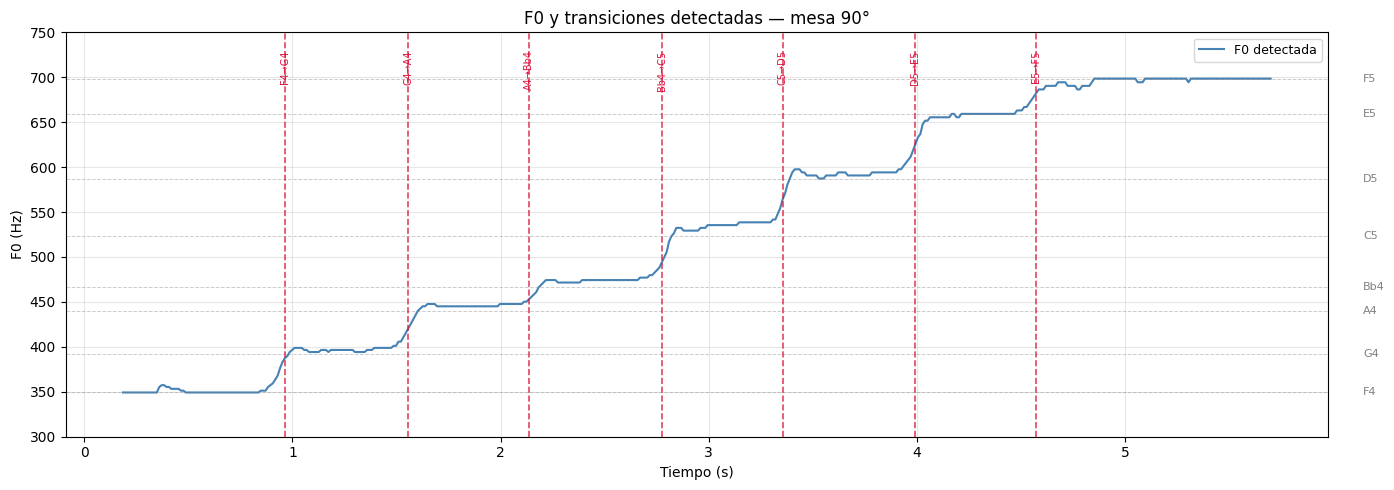

In [63]:
# ── Detectar transiciones para una sola referencia ────────────────────────────
ANG_PRUEBA = 90   # ángulo de mesa a analizar

f0     = f0_refs[ANG_PRUEBA]
prob   = prob_refs[ANG_PRUEBA]
voiced = voiced_refs[ANG_PRUEBA]

freqs_notas_arr  = np.array(list(NOTAS.values()))
nombres_notas_arr = list(NOTAS.keys())

# ── Asignar nota más cercana a cada frame con voz ─────────────────────────────
nota_por_frame = np.full(len(f0), '', dtype=object)

for i in range(len(f0)):
    if not voiced[i] or prob[i] < UMBRAL_CONFIANZA or np.isnan(f0[i]):
        continue
    cents        = 1200 * np.log2(f0[i] / freqs_notas_arr)
    idx_cercana  = np.argmin(np.abs(cents))
    if np.abs(cents[idx_cercana]) < 100:   # dentro de ±100 cents de alguna nota
        nota_por_frame[i] = nombres_notas_arr[idx_cercana]

# ── Detectar momentos de transición ───────────────────────────────────────────
# Una transición ocurre cuando la nota cambia de un frame al siguiente
transiciones = []   # lista de (frame_idx, nota_anterior, nota_nueva)

nota_actual = ''
for i in range(len(nota_por_frame)):
    n = nota_por_frame[i]
    if n == '' or n == nota_actual:
        continue
    if nota_actual != '':   # ignorar el primer onset
        transiciones.append((i, nota_actual, n))
    nota_actual = n

print(f"Transiciones detectadas para mesa {ANG_PRUEBA}°:")
for idx, n_ant, n_new in transiciones:
    t = tiempos[idx]
    print(f"  t={t:.3f}s  {n_ant} → {n_new}")

# ── Graficar ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

# F0 con voz
f0_plot = f0.copy()
f0_plot[~voiced] = np.nan
ax.plot(tiempos, f0_plot, color='steelblue', linewidth=1.5, label='F0 detectada')

# Líneas horizontales de notas
for nombre, freq in NOTAS.items():
    ax.axhline(freq, color='gray', linestyle='--', linewidth=0.7, alpha=0.4)
    ax.text(tiempos[-1] + 0.05, freq, nombre, fontsize=8, va='center', color='gray')

# Líneas verticales de transición
colores_trans = plt.cm.Set1.colors
for k, (idx, n_ant, n_new) in enumerate(transiciones):
    t = tiempos[idx]
    ax.axvline(t, color='crimson', linewidth=1.2, linestyle='--', alpha=0.8)
    ax.text(t, 730, f'{n_ant}→{n_new}', fontsize=7, ha='center',
            color='crimson', rotation=90, va='top')

ax.set_xlabel('Tiempo (s)')
ax.set_ylabel('F0 (Hz)')
ax.set_title(f'F0 y transiciones detectadas — mesa {ANG_PRUEBA}°')
ax.set_ylim(300, 750)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Detección nota por nota

Gap fin:      100 ms = 8 frames
Pre-pico:     0 ms = 0 frames
Umbral deriv: 5.0 cents/frame

  F4: pico=t=0.360s  inicio=t=0.360s → t=0.871s  (511 ms)
  G4: pico=t=0.964s  inicio=t=0.964s → t=1.463s  (499 ms)
  A4: pico=t=1.556s  inicio=t=1.556s → t=2.043s  (488 ms)
  Bb4: pico=t=2.183s  inicio=t=2.183s → t=2.682s  (499 ms)
  C5: pico=t=2.810s  inicio=t=2.810s → t=3.262s  (453 ms)
  D5: pico=t=3.355s  inicio=t=3.355s → t=3.901s  (546 ms)
  E5: pico=t=4.029s  inicio=t=4.029s → t=4.481s  (453 ms)
  F5: pico=t=4.772s  inicio=t=4.772s → t=6.002s  (1231 ms)


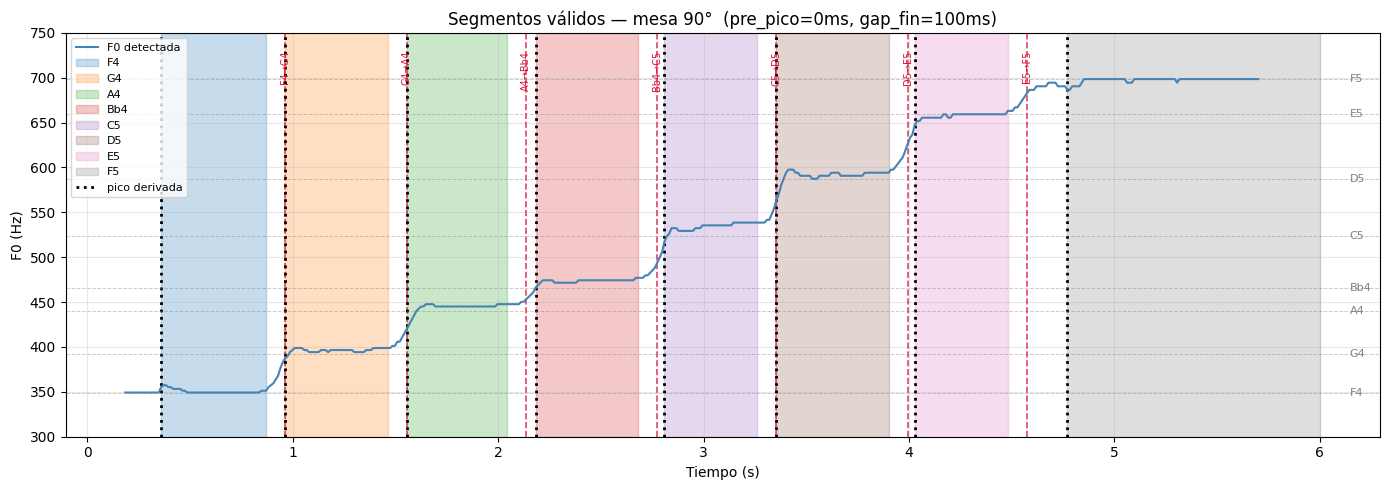

In [85]:
# ── Parámetros (ajustables) ────────────────────────────────────────────────────
GAP_FIN_MS = int(globals().get('GAP_FIN_MS', 100))
UMBRAL_DERIV = float(globals().get('UMBRAL_DERIV', 5))
PRE_PICO_MS = int(globals().get('PRE_PICO_MS', 0))
UMBRAL_CONFIANZA = float(globals().get('UMBRAL_CONFIANZA', 0.8))

GAP_FIN_FRAMES = int(GAP_FIN_MS / 1000 * sr_global / 512)
PRE_PICO_FRAMES = int(PRE_PICO_MS / 1000 * sr_global / 512)

print(f"Gap fin:      {GAP_FIN_MS} ms = {GAP_FIN_FRAMES} frames")
print(f"Pre-pico:     {PRE_PICO_MS} ms = {PRE_PICO_FRAMES} frames")
print(f"Umbral deriv: {UMBRAL_DERIV} cents/frame")
print()

# ── Función de detección ───────────────────────────────────────────────────────

def detectar_inicio_por_derivada(f0_local, voiced_local, prob_local,
                                  frame_transicion, frame_fin,
                                  pre_pico_frames=PRE_PICO_FRAMES):
    """
    Retorna (frame_inicio, frame_pico) o (None, None) si no encuentra.
    """
    derivada = np.zeros(len(f0_local), dtype=np.float64)
    for i in range(1, len(f0_local) - 1):
        if (voiced_local[i] and voiced_local[i - 1] and
                np.isfinite(f0_local[i]) and np.isfinite(f0_local[i - 1])):
            derivada[i] = abs(1200 * np.log2(f0_local[i] / f0_local[i - 1]))

    ventana = derivada[frame_transicion:frame_fin]
    if len(ventana) == 0:
        return None, None

    idx_pico = int(np.argmax(ventana) + frame_transicion)
    frame_inicio = max(frame_transicion, idx_pico - pre_pico_frames)

    for i in range(frame_inicio, frame_fin):
        if voiced_local[i] and np.isfinite(f0_local[i]) and prob_local[i] >= UMBRAL_CONFIANZA:
            return i, idx_pico

    return None, idx_pico


# ── Variables locales para trabajar con seguridad ─────────────────────────────
# Se usan valores por defecto si la celda se ejecuta de forma aislada.
f0_local = np.asarray(f0, dtype=np.float64)
voiced_local = np.asarray(voiced, dtype=bool)
prob_local = np.asarray(prob_refs.get(ANG_PRUEBA, np.ones_like(f0_local)), dtype=np.float64)

# ── Construir segmentos ────────────────────────────────────────────────────────
segmentos = {n: [] for n in nombres_notas_arr}
picos_deriv = []

transiciones = [t for t in transiciones if t[0] < len(f0_local)]

if not transiciones:
    print(f"No hay transiciones detectadas para mesa {ANG_PRUEBA}°; no se generan segmentos.")
else:
    puntos = [0] + [idx for idx, _, _ in transiciones] + [len(f0_local) - 1]

    # ── Primer segmento: F4 (onset desde silencio) ────────────────────────────────
    primera_nota = transiciones[0][1]
    primera_trans = puntos[1]

    frame_onset = None
    for i in range(puntos[0], primera_trans):
        if (voiced_local[i] and prob_local[i] >= UMBRAL_CONFIANZA and np.isfinite(f0_local[i])):
            frame_onset = i
            break

    if frame_onset is not None:
        picos_deriv.append(frame_onset)
        frame_inicio_f4 = max(puntos[0], frame_onset - PRE_PICO_FRAMES)
        frame_fin_f4 = primera_trans - GAP_FIN_FRAMES
        if frame_fin_f4 > frame_inicio_f4:
            segmentos[primera_nota].append((frame_inicio_f4, frame_fin_f4))
            dur_ms = (frame_fin_f4 - frame_inicio_f4) * 512 / sr_global * 1000
            print(f"  {primera_nota}: pico=t={tiempos[frame_onset]:.3f}s  "
                  f"inicio=t={tiempos[frame_inicio_f4]:.3f}s → "
                  f"t={tiempos[frame_fin_f4]:.3f}s  ({dur_ms:.0f} ms)")
    else:
        print(f"  {primera_nota}: no se detectó onset → descartado")

    # ── Resto de notas ─────────────────────────────────────────────────────────────
    for k in range(len(transiciones)):
        nota = transiciones[k][2]
        t_inicio = puntos[k + 1]
        t_fin = puntos[k + 2] if k + 2 < len(puntos) else len(f0_local) - 1

        frame_inicio, frame_pico = detectar_inicio_por_derivada(
            f0_local, voiced_local, prob_local, t_inicio, t_fin
        )

        if frame_pico is not None:
            picos_deriv.append(frame_pico)

        if frame_inicio is None:
            print(f"  {nota}: no se detectó inicio → descartado")
            continue

        frame_fin_valido = t_fin - GAP_FIN_FRAMES
        if frame_fin_valido > frame_inicio:
            segmentos[nota].append((frame_inicio, frame_fin_valido))
            dur_ms = (frame_fin_valido - frame_inicio) * 512 / sr_global * 1000
            print(f"  {nota}: pico=t={tiempos[frame_pico]:.3f}s  "
                  f"inicio=t={tiempos[frame_inicio]:.3f}s → "
                  f"t={tiempos[frame_fin_valido]:.3f}s  ({dur_ms:.0f} ms)")
        else:
            print(f"  {nota}: segmento demasiado corto → descartado")

# ── Graficar ───────────────────────────────────────────────────────────────────
colores_notas = dict(zip(nombres_notas_arr, plt.cm.tab10.colors))

fig, ax = plt.subplots(figsize=(14, 5))

f0_plot = f0_local.copy()
f0_plot[~voiced_local] = np.nan
ax.plot(tiempos, f0_plot, color='steelblue', linewidth=1.5,
        label='F0 detectada', zorder=3)

# Sombreado de segmentos válidos
for nota, segs in segmentos.items():
    for (f_ini, f_fin) in segs:
        ax.axvspan(tiempos[f_ini], tiempos[f_fin],
                   color=colores_notas[nota], alpha=0.25, label=nota)

# Líneas verticales de transición (crimson)
for idx, n_ant, n_new in transiciones:
    ax.axvline(tiempos[idx], color='crimson', linewidth=1.2,
               linestyle='--', alpha=0.8)
    ax.text(tiempos[idx], 730, f'{n_ant}→{n_new}',
            fontsize=7, ha='center', color='crimson', rotation=90, va='top')

# Líneas verticales de picos de derivada (naranja)
for fp in picos_deriv:
    ax.axvline(tiempos[fp], color='black', linewidth=2,
               linestyle=':', alpha=1, label='pico derivada')

# Líneas horizontales de notas
for nombre, freq in NOTAS.items():
    ax.axhline(freq, color='gray', linestyle='--', linewidth=0.7, alpha=0.4)
    ax.text(tiempos[-1] + 0.05, freq, nombre,
            fontsize=8, va='center', color='gray')

handles, labels = ax.get_legend_handles_labels()
vistos = {}
for h, l in zip(handles, labels):
    if l not in vistos:
        vistos[l] = h
ax.legend(vistos.values(), vistos.keys(), fontsize=8, loc='upper left')

ax.set_xlabel('Tiempo (s)')
ax.set_ylabel('F0 (Hz)')
ax.set_title(f'Segmentos válidos — mesa {ANG_PRUEBA}°  '
             f'(pre_pico={PRE_PICO_MS}ms, gap_fin={GAP_FIN_MS}ms)')
ax.set_ylim(300, 750)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()